In [2]:
!pip install torch transformers datasets tqdm matplotlib

# 1. 기초 설정 + 데이터 불러오기

In [3]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

from torch.utils.data import Dataset, DataLoader
from transformers import GPT2TokenizerFast
from datasets import load_dataset
from tqdm.auto import tqdm

In [4]:
# 기본 설정

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda
GPU: Tesla T4


# 2. GPT-2 tokenizer

In [6]:
# GPT-2 tokenizer 설정

tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
tokenizer.model_max_length = int(1e9)

vocab_size = tokenizer.vocab_size

print("vocab_size:", vocab_size)
print("eos_token:", tokenizer.eos_token)
print("eos_token_id:", tokenizer.eos_token_id)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

vocab_size: 50257
eos_token: <|endoftext|>
eos_token_id: 50256


# 3. Dataset 불러오기 + DataLoader 설정

In [5]:
# OpenWebText 데이터 불러오기
# 전체를 다운로드하지 않고 streaming 방식으로 순차적으로 읽음

dataset = load_dataset(
    "Skylion007/openwebtext",
    split="train",
    streaming=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

OpenWebText 문서를 하나씩 읽으면서 GPT-2 tokenizer로 token id로 바꾸고, 총 500만 개 token이 모이면 멈춘 뒤 PyTorch tensor로 저장



In [7]:
# OpenWebText에서 500만 token만 수집

max_tokens = 5_000_000
all_ids = []

pbar = tqdm(total=max_tokens)

for example in dataset:
    text = example["text"]

    # 문서 끝마다 GPT-2의 end-of-text token 추가
    ids = tokenizer.encode(text + tokenizer.eos_token)

    remaining = max_tokens - len(all_ids)

    if len(ids) >= remaining:
        all_ids.extend(ids[:remaining])
        pbar.update(remaining)
        break
    else:
        all_ids.extend(ids)
        pbar.update(len(ids))

pbar.close()

data = torch.tensor(all_ids, dtype=torch.long)

print("총 token 개수:", len(data))
print("data shape:", data.shape)
print("vocab_size:", vocab_size)

  0%|          | 0/5000000 [00:00<?, ?it/s]

총 token 개수: 5000000
data shape: torch.Size([5000000])
vocab_size: 50257


In [8]:
class NextTokenDataset(Dataset):

    def __init__(self, data, block_size):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.block_size]
        y = self.data[idx + 1 : idx + self.block_size + 1]
        return x, y


block_size = 256
batch_size = 8
dataset = NextTokenDataset(data, block_size)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

# batch shape 확인
xb, yb = next(iter(loader))

print("xb.shape:", xb.shape)
print("yb.shape:", yb.shape)

xb.shape: torch.Size([8, 256])
yb.shape: torch.Size([8, 256])


Head attention : embedding dimension을 head 개수로 나누어서 attention하면 다양한 맥락에서 token을 볼 수 있음.

(B,T,emb_dim) -> (B,T,head_size)

# 4-1 Multi - head attention

In [9]:
class Head(nn.Module):

    def __init__(self, emb_dim, head_size, block_size, dropout=0.1): #emb_dim, head_size(emb_dim을 몇개로 쪼갤건지), block size 변수로 저장
        super().__init__()

        self.key = nn.Linear(emb_dim, head_size, bias=False) # emb_dim -> head_size 차원 변경
        self.query = nn.Linear(emb_dim, head_size, bias=False)
        self.value = nn.Linear(emb_dim, head_size, bias=False)

        # causal mask
        self.register_buffer(
            "tril",
            torch.tril(torch.ones(block_size, block_size)) # trill이라는 이름으로 [T,T] 하삼각행렬 구성
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x): # 실제 계산
        B, T, C = x.shape # (C = emb_dim)

        k = self.key(x)      # (B, T, head_size)
        q = self.query(x)    # (B, T, head_size)
        v = self.value(x)    # (B, T, head_size)

        # attention score

        wei = q @ k.transpose(-2, -1) * (k.size(-1) ** -0.5)

        # 미래 token 가리기
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))

        # attention 확률
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        # value 가중합
        out = wei @ v        # (B, T, head_size)

        return out  # (B,T,emb_dim) -> (B,T,head_size)

(B,T,head_size)를 묶어서 (B,T,emb_dim)의 multi-head attention을 만드는 것

즉, 여러개의 Head를 병렬로 실행한 뒤 결과를 합치는 모델

In [10]:
class MultiHeadAttention(nn.Module):

    def __init__(self, emb_dim, num_heads, block_size, dropout=0.1):
        super().__init__()

        assert emb_dim % num_heads == 0   # emb_dim은 num_heads 로 나누어 떨어져야 한다.

        head_size = emb_dim // num_heads

        self.heads = nn.ModuleList([
            Head(emb_dim, head_size, block_size, dropout)   # num_heads 만큼 Head 만들기
            for _ in range(num_heads)
        ])


        self.proj = nn.Linear(emb_dim, emb_dim) #

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # 각 head 결과를 마지막 차원에서 이어붙임
        out = torch.cat([h(x) for h in self.heads], dim=-1)  # h(x) = (B, T, head_size) / cat -> (B,T,head_size * num_heads)

        out = self.proj(out)
        out = self.dropout(out)

        return out # (B,T,head_size) -> (B,T,emb_size)

# 4-2. FeedForward

In [11]:
class FeedForward(nn.Module):

    def __init__(self, emb_dim, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(               # 여러 Layer을 하나로 묶음
            nn.Linear(emb_dim, 4 * emb_dim),    # token 표현을 더 넓은 공간에서, (B,T,emb) -> (B,T,4*emb)
            nn.GELU(),                          # GELU : 비선형 변환 함수
            nn.Linear(4 * emb_dim, emb_dim),    # 다시 차원 축소 (원래대로)
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

# 4-3. Block

In [12]:
class Block(nn.Module):

    def __init__(self, emb_dim, num_heads, block_size, dropout=0.1):
        super().__init__()

        self.ln1 = nn.LayerNorm(emb_dim)
        self.sa = MultiHeadAttention(emb_dim, num_heads, block_size, dropout)

        self.ln2 = nn.LayerNorm(emb_dim)
        self.ffwd = FeedForward(emb_dim, dropout)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x)) # residual connection
        return x


# 4-4. MiniGPT2

In [13]:
class MiniGPT2(nn.Module):


    def __init__(
        self,
        vocab_size,
        block_size,
        emb_dim=256,
        num_heads=8,
        num_layers=6,
        dropout=0.1
    ):
        super().__init__()

        self.block_size = block_size

        self.token_embedding = nn.Embedding(vocab_size, emb_dim) # [V,emb] 의 행렬 생성
        self.position_embedding = nn.Embedding(block_size, emb_dim) # [T, emb] 의 행렬 생성

        self.blocks = nn.Sequential(*[
            Block(emb_dim, num_heads, block_size, dropout)
            for _ in range(num_layers)
        ])

        self.ln_f = nn.LayerNorm(emb_dim) #Final Layernorm

        self.lm_head = nn.Linear(emb_dim, vocab_size, bias=False) # [B,T,C] -> [B,T,vocab_size]

        self.drop = nn.Dropout(dropout)


    def forward(self, x):
        B, T = x.shape

        assert T <= self.block_size

        # 위치 index
        pos = torch.arange(T, device=x.device)

        # token embedding
        tok = self.token_embedding(x)           # (B, T, emb_dim)

        # position embedding
        pos = self.position_embedding(pos)[None]  # (1, T, emb_dim)

        # token 정보 + 위치 정보
        h = tok + pos
        h = self.drop(h)

        # Transformer blocks
        h = self.blocks(h)

        # final layer norm
        h = self.ln_f(h)

        # 다음 token 예측 logits
        logits = self.lm_head(h)                # (B, T, vocab_size)

        return logits

# 4-5. 모델 생성

In [14]:
emb_dim = 256
num_heads = 8
num_layers = 6
dropout = 0.1

model = MiniGPT2(
    vocab_size=vocab_size,
    block_size=block_size,
    emb_dim=emb_dim,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout
).to(device)

logits = model(xb.to(device)) #xb = [B,T] -> (embedding) [B,T,emb] -> (single-head) [B,T,emb/n_heads] -> (multi-head) [B,T,emb] -> (FeedForward)

print("logits.shape:", logits.shape)

logits.shape: torch.Size([8, 256, 50257])


# 5. 학습

In [15]:
def sequence_cross_entropy(logits, targets):

    return F.cross_entropy(logits.transpose(1, 2), targets)

def train_one_epoch(model, loader, optimizer, device, max_steps=None):
    model.train()

    total_loss = 0.0
    total_count = 0

    for step, (xb, yb) in enumerate(tqdm(loader)):
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = sequence_cross_entropy(logits, yb)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_count += xb.size(0)

        if max_steps is not None and step + 1 >= max_steps:
            break

    return total_loss / total_count

In [16]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

train_losses = []

for epoch in range(100):
    train_loss = train_one_epoch(
        model,
        loader,
        optimizer,
        device,
        max_steps=300
    )

    train_losses.append(train_loss)

    print(f"epoch {epoch:2d} | train loss {train_loss:.4f}")

  0%|          | 0/624968 [00:00<?, ?it/s]

epoch  0 | train loss 7.5544


  0%|          | 0/624968 [00:00<?, ?it/s]

epoch  1 | train loss 6.8593


  0%|          | 0/624968 [00:00<?, ?it/s]

...

epoch 97 | train loss 4.3386


  0%|          | 0/624968 [00:00<?, ?it/s]

epoch 98 | train loss 4.3542


  0%|          | 0/624968 [00:00<?, ?it/s]

epoch 99 | train loss 4.3291


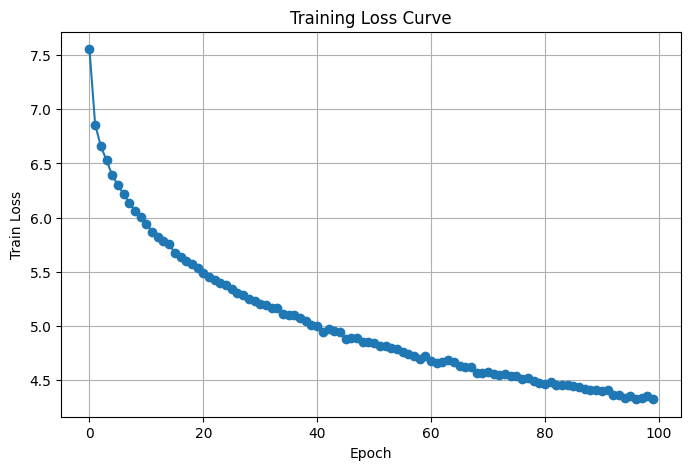

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Curve")

plt.grid(True)
plt.show()

# 6. Sampling

In [21]:
def top_k_filter(logits, top_k):

    if top_k is None:
        return logits

    values, _ = torch.topk(logits, top_k)
    min_values = values[:, -1].unsqueeze(1)

    logits = torch.where(
        logits < min_values,
        torch.full_like(logits, float("-inf")),
        logits
    )

    return logits

In [24]:
@torch.no_grad()
def sample_gpt(model, block_size, tokenizer, device,
               start_text="In recent years,",
               max_new_tokens=500,
               temperature=0.8,
               top_k=50):

    model.eval()

    input_ids = tokenizer.encode(start_text)

    context = torch.zeros((1, block_size), dtype=torch.long, device=device)

    for token_id in input_ids:
        ix = torch.tensor([[token_id]], dtype=torch.long, device=device)
        context = torch.cat([context[:, 1:], ix], dim=1)

    out_ids = input_ids.copy()

    for _ in range(max_new_tokens):
        logits = model(context)
        logits = logits[:, -1, :]

        # temperature 적용
        logits = logits / temperature

        # top-k 적용
        logits = top_k_filter(logits, top_k)

        probs = F.softmax(logits, dim=-1)
        ix = torch.multinomial(probs, num_samples=1)

        out_ids.append(ix.item())

        context = torch.cat([context[:, 1:], ix], dim=1)

    return tokenizer.decode(out_ids)

In [25]:
print(
    sample_gpt(
        model,
        block_size,
        tokenizer,
        device,
        start_text="In recent years,",
        max_new_tokens=500,
        temperature=0.8,
        top_k=50
    )
)

In recent years, I’ll be laughing!

Oh!

So!

So wait I’ve got out there to go up for the next couple. A little pictures

What’ The most thing I’ve done this film out for the next step we’ve been working for.

So I’ve got into the fun since I had a bunch of years old. I love it. We’ve been a lot of other places. I feel that we’ve done, but it’s quite funny.

If you’ve read the videos, then go ahead of the show. The story is a new movie that I have been so many fun to see if it’s gone.

I’ve always tried to put together it together, as I get it. You can’t let alone feel you can’t get you out there.

Yeah don’t forget anything like there for it.

This is my first, and I’ve enjoyed it from quite like I’m really excited to be out of it. I want to try it together and just get a bit fun to help you do something.

I always love the time. That’s because I’m really good. I’m getting excited that I’m going to say it’s not going to be a real life. It’s a good thing.

I was a very high quality, an